In [8]:
import zipfile
import pandas as pd

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['default', 'science', 'no-latex'])

from code_utils.utils_basic import PROJECT_PATH

In [9]:
def load_csv_from_zip(zip_path, csv_path, **kwargs):
    """
    Load a CSV file from a ZIP archive into a pandas DataFrame.
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(csv_path) as f:
            df = pd.read_csv(f, **kwargs)
    return df

# 1. Clustering criterion

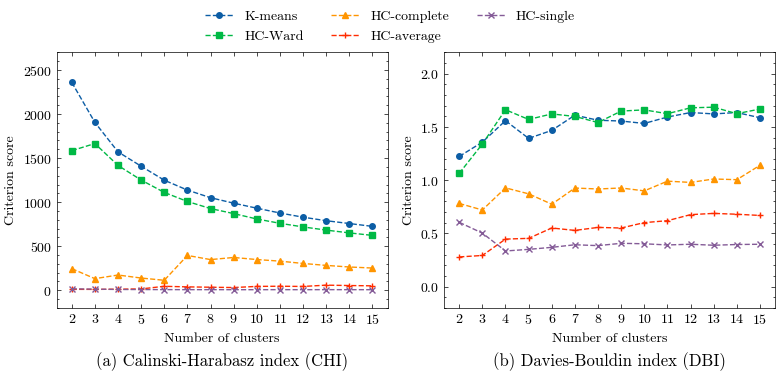

In [10]:
zip_path = PROJECT_PATH / 'results/results.zip'

# Load data
data = load_csv_from_zip(
    zip_path,
    csv_path = 'clustering/clustering_criteria.csv',
    index_col = 0, header = [0,1])
data.columns = data.columns.swaplevel(0)


# Model types, line styles
model_labels = {
    'kmeans': 'K-means',
    'hierarchical_ward'     : 'HC-Ward',
    'hierarchical_complete' : 'HC-complete',
    'hierarchical_average'  : 'HC-average',
    'hierarchical_single'   : 'HC-single',
}

# Metrics, subplots
metric_labels = {
    'calinski_harabasz_score': 'Calinski-Harabasz index (CHI)',
    'davies_bouldin_score'   : 'Davies-Bouldin index (DBI)',
    'silhouette_score'       : 'Silhouette index (SI)',
}


maker_li = ['o', 's', '^', '+', 'x']

#
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes = axes.flatten()

for _ix, _metric in enumerate([
    'calinski_harabasz_score',
    'davies_bouldin_score',
]):

    plot_data = (data[_metric].copy()
        .rename(columns=model_labels)
    )

    ax = axes[_ix]

    for _j, _col in enumerate(plot_data.columns.to_list()):

        ax.plot(
            plot_data.index.to_list(),
            plot_data[_col].to_list(),
            marker = maker_li[_j],
            markersize = 4,
            linewidth = 1.0,
            linestyle = '--',
            label = _col,
        )

    # Axis configurations
    ax.set_xlabel('Number of clusters')
    ax.set_xticks(plot_data.index.to_list())
    # Add y-axis label
    ax.set_ylabel('Criterion score')
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)

    if _metric == 'calinski_harabasz_score':
        ax.set_ylim(-200, 2700)
    elif _metric == 'davies_bouldin_score':
        ax.set_ylim(-0.2, 2.2)

    # Add figure caption
    ax.text(
        0.5, -0.17,
        f'({chr(97 + _ix)}) {metric_labels[_metric]}',
        ha = 'center', va = 'top',
        transform = ax.transAxes,
        fontsize = 12,
    )

# Add legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc = 'lower center',
    bbox_to_anchor = (0.5, 0.95),
    ncol = 3,
    fontsize = 10,
    frameon = False,
)

plt.tight_layout()
# Save figure
# fig.savefig(PROJECT_PATH / 'figures/clustering/clustering_criterion.jpg',
#     dpi=600, bbox_inches='tight')
# fig.savefig(PROJECT_PATH / 'figures/clustering/clustering_criterion.pdf',
#     format='pdf',
#     bbox_inches='tight')

# 2. Clustering number and cluster centers

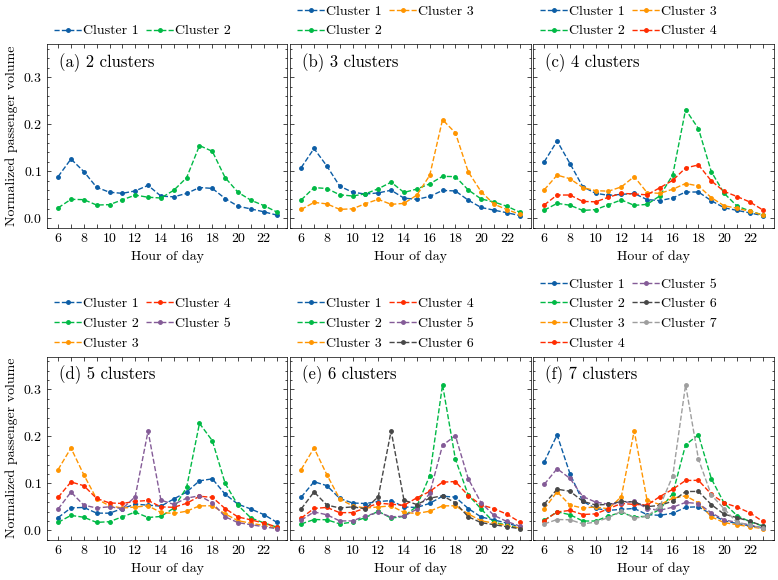

In [11]:
# Load data
data = load_csv_from_zip(
    zip_path,
    csv_path = 'clustering/clustering_centers.csv',
    index_col = 0, header = [0,1])

# figure configurations
fig, axes = plt.subplots(2, 3, figsize=(8.0, 6), sharex=False, sharey=True)
axes = axes.flatten()

for _ix, _n_cluster in enumerate([2, 3, 4, 5, 6, 7]):

    plot_data = (data[str(_n_cluster)].copy()
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    ax = axes[_ix]

    ax = plot_data.plot(ax = ax,
        marker = 'o',
        markersize = 2.5,
        linewidth = 1.0,
        linestyle = '--',
        legend = True,
    )

    # revise legend
    ax.legend(loc='lower left', bbox_to_anchor=(0.0, 1.0), ncols=2,
        borderpad=0, columnspacing=0.5, handletextpad=0.1)

    ax.set_xticks(plot_data.index.to_list())
    ax.set_xticklabels([i if (i % 2 ==0) else '' for i in plot_data.index.to_list()])
    ax.set_ylim([-0.02, 0.37])
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Normalized passenger volume')
    # Add figure caption
    ax.text(
        0.05, 0.95,
        f'({chr(97 + _ix)}) {_n_cluster} clusters',
        ha = 'left', va = 'top',
        transform = ax.transAxes,
        fontsize = 12,
    )


plt.tight_layout(w_pad=0.1)
# Save figure
# fig.savefig(PROJECT_PATH / 'figures/clustering/clustering_centers.jpg',
#     dpi=600, bbox_inches='tight')
# fig.savefig(PROJECT_PATH / 'figures/clustering/clustering_centers.pdf',
#     format='pdf', bbox_inches='tight')

# 3. Cluster members

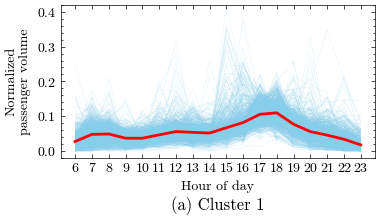

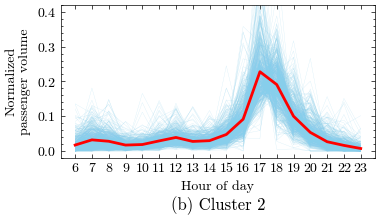

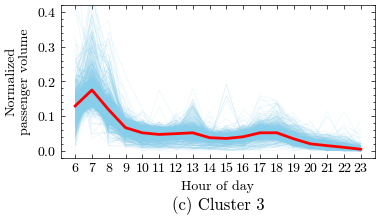

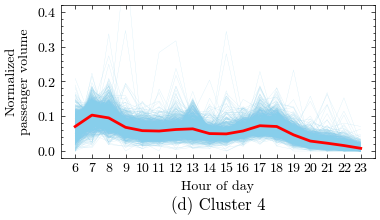

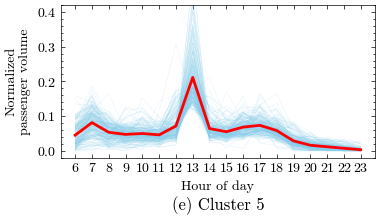

In [12]:
# Load data
data = load_csv_from_zip(
    zip_path,
    csv_path = 'clustering/clustering_results_kmeans.csv',
    index_col=0, header=0,
    dtype = {'pt_code': str})
# process index
data.index = data.index.str.zfill(5)

# Cluster labels
cluster_label_li = data['label'].unique().tolist()
cluster_label_li.sort()

color_li = []


# fig, axes = plt.subplots(3, 2, figsize=(8, 6), sharex=False, sharey=False)
# axes = axes.flatten()

for _ix, _cluster_label in enumerate(cluster_label_li):

    plot_data = (data
        .copy()
        .query('`label` == @_cluster_label')
        .sort_index(axis=0)
        .drop(columns=['label'])
    )

    # convert index to int
    plot_data.columns = plot_data.columns.map(int)
    # xticklabels
    xticklabel_li = plot_data.columns.to_list()

    # ax = axes[_ix]
    fig, ax = plt.subplots(1, 1, figsize=(4, 2.5), sharex=False, sharey=False)

    # Plot member
    ax = plot_data.T.plot(ax = ax,
        linewidth = 0.2,
        linestyle = '-',
        alpha = 0.4,
        color = 'skyblue',
        legend = False,
    )
    # Plot cluster center
    cluster_center = plot_data.mean(axis=0).plot(
        ax = ax,
        linewidth = 2.0,
        color = 'red',
        legend = False,
    )

    ax.set_xticks(xticklabel_li)
    ax.set_xticklabels(xticklabel_li)
    ax.set_ylim([-0.02, 0.42])
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Normalized\npassenger volume')
    # Add figure caption
    ax.text(
        0.5, -0.25,
        f'({chr(97 + _ix)}) Cluster {_cluster_label + 1}',
        ha = 'center', va = 'top',
        transform = ax.transAxes,
        fontsize = 12,
    )

    fig.tight_layout()
    # Save figure
    # fig.savefig(SAVE_FOLDER / f'clustering_member_cluster_{str(_cluster_label + 1)}.jpg',
    #     dpi=600, bbox_inches='tight')

# 4. Spatial kernel density of clusters

In [15]:
import geopandas as gpd
import seaborn as sns

from code_utils.utils_basic import PROJECTED_CRS

In [16]:
# Load data
data = load_csv_from_zip(
    zip_path,
    csv_path = 'clustering/clustering_results_kmeans.csv',
    index_col = 0, header = 0,
    dtype = {'pt_code': str})
# process index
data.index = data.index.str.zfill(5)


# bus stop postal codes
busstop = (
    load_csv_from_zip(
        zip_path = PROJECT_PATH / 'data/bus_network/bus_info_202210.zip',
        csv_path = 'bus_stop_20221020.csv',
        dtype = {'BusStopCode': str},
        index_col = None, header = 0,)
    .assign(pt_code = lambda x: x['BusStopCode'].str.zfill(5),)
)

busstop = (
    gpd.GeoDataFrame(
        busstop,
        geometry = gpd.points_from_xy(busstop['Longitude'], busstop['Latitude']),
        crs = 'EPSG:4326',)
    .to_crs(PROJECTED_CRS)
    .assign(
        proj_x = lambda x: x.geometry.x,
        proj_y = lambda x: x.geometry.y,
    )
)


# Merge clustering results with bus stop locations
data = (data[['label']].copy()
    .reset_index()
    .merge(
        busstop[['pt_code', 'proj_x', 'proj_y']],
        on = 'pt_code',
        how = 'left',)
    .assign(flag = 1)
)


# Load zone
file_path = (
    (PROJECT_PATH / 'data/planning_area.zip').as_posix() +
    '!planning_area.geojson'
)
zone = gpd.read_file(file_path)
if zone.crs.equals(PROJECT_PATH):
    zone = zone.to_crs(PROJECTED_CRS)

C:\Users\Wei Zhou\AppData\Local\Temp\ipykernel_29656\3375988551.py:28: UserWarning: 

`shade_lowest` has been replaced by `thresh`; setting `thresh=0.05.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(
C:\Users\Wei Zhou\AppData\Local\Temp\ipykernel_29656\3375988551.py:28: UserWarning: 

`shade_lowest` has been replaced by `thresh`; setting `thresh=0.05.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(
C:\Users\Wei Zhou\AppData\Local\Temp\ipykernel_29656\3375988551.py:28: UserWarning: 

`shade_lowest` has been replaced by `thresh`; setting `thresh=0.05.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(
C:\Users\Wei Zhou\AppData\Local\Temp\ipykernel_29656\3375988551.py:28: UserWarning: 

`shade_lowest` has been replaced by `thresh`; setting `thresh=0.05.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(
C:\Users\Wei Zho

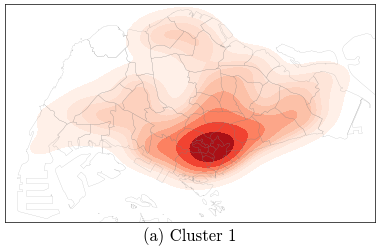

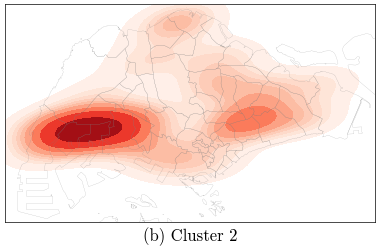

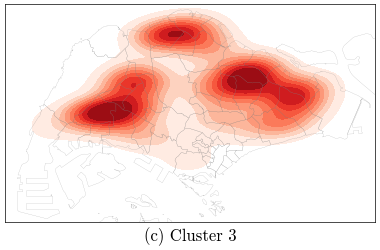

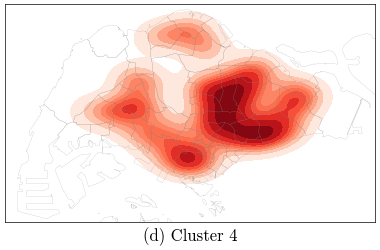

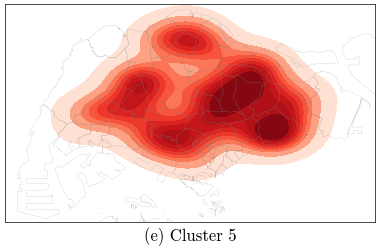

In [17]:
cluster_label_li = data['label'].unique().tolist()
cluster_label_li.sort()


# fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharex=True, sharey=True)
# axes = axes.flatten()
# for ax in axes[len(cluster_label_li):]:
#     ax.axis('off')

for _ix, _cluster_label in enumerate(cluster_label_li):

    plot_data = (data
        .copy()
        .query('`label` == @_cluster_label')
    )

    # ax = axes[_ix]
    fig, ax = plt.subplots(1, 1, figsize=(4, 3))

    # Plot zone boundary
    ax = zone.boundary.plot(
        ax = ax,
        color = 'grey',
        linewidth = 0.1,
    )

    # Plot spatial distribution of bus stops
    ax = sns.kdeplot(
        data = plot_data,
        x = 'proj_x', y = 'proj_y', fill=True,
        cmap="Reds", shade_lowest=False,
        ax = ax,
    )

    ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
    ax.set_xlim([1000,  52000])
    ax.set_ylim([21000, 51000])
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Add figure caption
    ax.text(
        0.5, -0.02,
        f'({chr(97 + _ix)}) Cluster {_cluster_label + 1}',
        ha = 'center', va = 'top',
        transform = ax.transAxes,
        fontsize = 12,
    )

    fig.tight_layout()
    # Save figure
    # fig.savefig(SAVE_FOLDER / f'clustering_spatial_kde_cluster_{str(_cluster_label + 1)}.jpg',
    #     dpi=600, bbox_inches='tight')